<a href="https://colab.research.google.com/github/georginakinuthia/georginakinuthia.github.io/blob/main/AMB_310826.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install duckdb geopandas shapely

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DONE! Isolated 32943 Tacubaya crime points.


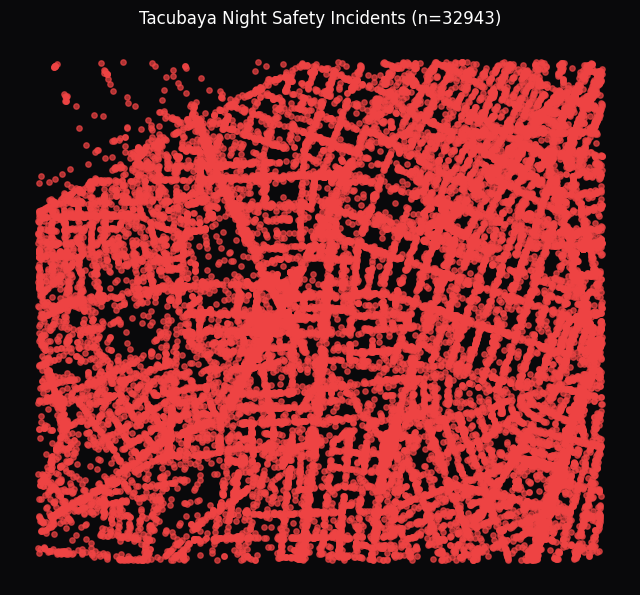

In [ ]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt

# Paste your copied path between the quotes below:
csv_path = "/content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/raw_data/Crime & Safety Victimas FGJ_acumulado_2024_09.csv"

# 1. Query ONLY Tacubaya coordinates directly in 3 seconds
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

query = f"""
    SELECT
        TRY_CAST(longitud AS DOUBLE) as lon,
        TRY_CAST(latitud AS DOUBLE) as lat,
        ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
    FROM read_csv_auto('{csv_path}', ignore_errors=true)
    WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
      AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
"""

df = con.execute(query).df()

# 2. Convert to spatial GeoDataFrame instantly
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['geometry_wkt']),
    crs="EPSG:4326"
)

# 3. Save GeoJSON locally to Colab disk
gdf.to_file("/content/tacubaya_crime_local.geojson", driver="GeoJSON")
print(f"DONE! Isolated {len(gdf)} Tacubaya crime points.")

# 4. Generate immediate dark-mode map image for your slides
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#09090b')
ax.set_facecolor('#09090b')
gdf.plot(ax=ax, color='#ef4444', markersize=15, alpha=0.7)
plt.title(f"Tacubaya Night Safety Incidents (n={len(gdf)})", color='white', fontsize=12, pad=10)
plt.axis('off')
plt.savefig("/content/tacubaya_crime_map.png", dpi=200, bbox_inches='tight', facecolor='#09090b')
plt.show()

Loading street network from: /content/drive/Shareddrives/2026 NFI Mexico City/stage 03/Tacubaya_ABM_Data/raw_data/CDXM Street Sample 1.gpkg
Done! Created weighted network with 249 street segments.


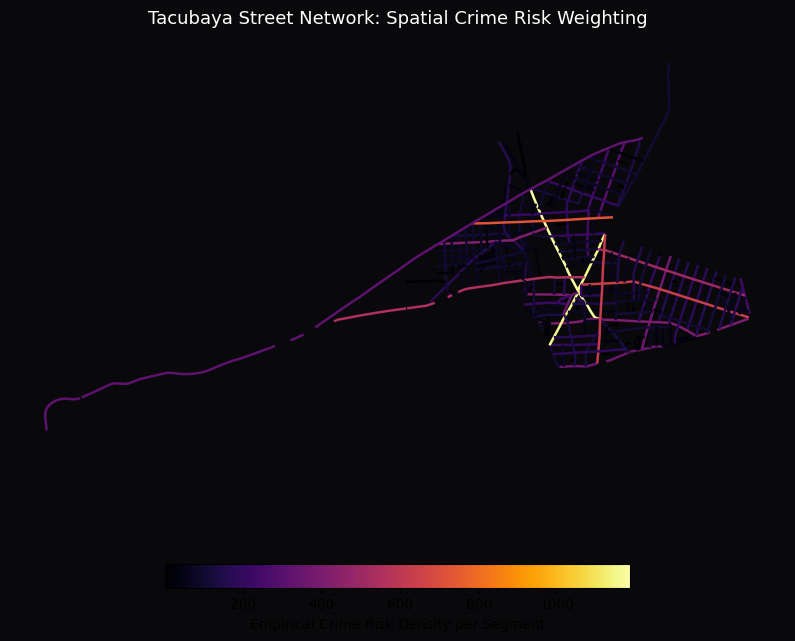

In [ ]:
import os
import glob
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Auto-detect path for CDXM Street Sample 1
street_matches = glob.glob("/content/drive/**/CDXM Street Sample 1*", recursive=True)
if not street_matches:
    raise FileNotFoundError("Could not locate 'CDXM Street Sample 1' in Drive.")

street_path = street_matches[0]
print(f"Loading street network from: {street_path}")

# 2. Read streets and load previously created crime layer
streets = gpd.read_file(street_path)
crimes = gpd.read_file("/content/tacubaya_crime_local.geojson")

# 3. Ensure matching projected Coordinate Reference System (EPSG:6372 - Mexico City UTM in meters)
streets_utm = streets.to_crs(epsg=6372)
crimes_utm = crimes.to_crs(epsg=6372)

# 4. Clip street network to Tacubaya study area bounding box
xmin, ymin, xmax, ymax = crimes_utm.total_bounds
streets_clipped = streets_utm.cx[xmin:xmax, ymin:ymax].copy()

# 5. Buffer street lines by 25 meters and count spatial crime intersections
streets_buffered = streets_clipped.geometry.buffer(25)
buffered_gdf = gpd.GeoDataFrame(streets_clipped.drop(columns='geometry'), geometry=streets_buffered, crs=6372)

# Join crime points to buffered streets
joined = gpd.sjoin(crimes_utm, buffered_gdf, how="inner", predicate="within")
crime_counts = joined.index_right.value_counts()

# Assign risk counts back to original linear street geometry
streets_clipped['crime_count'] = streets_clipped.index.map(crime_counts).fillna(0).astype(int)

# Normalize risk weight for routing (min weight = 1.0, high risk scales higher)
streets_clipped['risk_weight'] = 1.0 + (streets_clipped['crime_count'] / (streets_clipped['crime_count'].mean() + 1)) * 3.0

# 6. Save risk-weighted street layer locally
output_streets = "/content/tacubaya_streets_weighted.geojson"
streets_clipped.to_crs(epsg=4326).to_file(output_streets, driver="GeoJSON")
print(f"Done! Created weighted network with {len(streets_clipped)} street segments.")

# 7. Render Street Network Risk Map for slides
fig, ax = plt.subplots(figsize=(10, 10), facecolor='#09090b')
ax.set_facecolor('#09090b')

streets_clipped.plot(
    column='crime_count',
    cmap='inferno',
    linewidth=1.8,
    legend=True,
    ax=ax,
    legend_kwds={'label': "Empirical Crime Risk Density per Segment", 'orientation': "horizontal", 'shrink': 0.6}
)

plt.title("Tacubaya Street Network: Spatial Crime Risk Weighting", color='white', fontsize=13, pad=15)
plt.axis('off')
plt.savefig("/content/tacubaya_street_risk_map.png", dpi=200, bbox_inches='tight', facecolor='#09090b')
plt.show()

In [ ]:
import os
import glob
import duckdb
import geopandas as gpd
import networkx as nx
import folium
from folium.plugins import AntPath
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

# 2. Locate dataset paths directly
street_matches = glob.glob("/content/drive/**/CDXM Street Sample 1*", recursive=True)
csv_matches = glob.glob("/content/drive/**/Crime & Safety Victimas FGJ_acumulado_2024_09.csv", recursive=True)

if not street_matches:
    street_matches = glob.glob("/content/drive/**/*CDXM Street Sample*", recursive=True)
if not csv_matches:
    csv_matches = glob.glob("/content/drive/**/*FGJ_acumulado*.csv", recursive=True)

street_path = street_matches[0]
csv_path = csv_matches[0]

# 3. Query Tacubaya crime points via DuckDB
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")

query = f"""
    SELECT
        TRY_CAST(longitud AS DOUBLE) as lon,
        TRY_CAST(latitud AS DOUBLE) as lat,
        ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
    FROM read_csv_auto('{csv_path}', ignore_errors=true)
    WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
      AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
"""

df_crime = con.execute(query).df()
crimes = gpd.GeoDataFrame(df_crime, geometry=gpd.GeoSeries.from_wkt(df_crime['geometry_wkt']), crs="EPSG:4326")

# 4. Load & Explode Streets to guarantee pure LineString geometries
streets = gpd.read_file(street_path)

# Convert MultiLineStrings into individual LineString segments
streets = streets.explode(index_parts=False).reset_index(drop=True)
streets = streets[streets.geometry.notnull() & (streets.geometry.geom_type == 'LineString')].copy()

# Reproject to Mexico City metric system (EPSG:6372)
crimes_utm = crimes.to_crs(epsg=6372)
streets_utm = streets.to_crs(epsg=6372)

# Compute crime risk counts per segment
streets_buffered = streets_utm.geometry.buffer(25)
buffered_gdf = gpd.GeoDataFrame(streets_utm.drop(columns='geometry'), geometry=streets_buffered, crs=6372)

joined = gpd.sjoin(crimes_utm, buffered_gdf, how="inner", predicate="within")
crime_counts = joined.index_right.value_counts()

streets_utm['crime_count'] = streets_utm.index.map(crime_counts).fillna(0).astype(int)
streets_utm['risk_weight'] = 1.0 + (streets_utm['crime_count'] / (streets_utm['crime_count'].mean() + 1)) * 3.0

streets_wgs = streets_utm.to_crs(epsg=4326)

# 5. Build Routing Graph
G_baseline = nx.Graph()
G_intervention = nx.Graph()

for idx, row in streets_wgs.iterrows():
    geom = row.geometry
    if geom and geom.geom_type == 'LineString':
        coords = [(lat, lon) for lon, lat in geom.coords]
        if len(coords) < 2:
            continue

        length = geom.length
        cost_base = length * row.get('risk_weight', 1.0)
        cost_interv = length * 1.0  # CPTED intervention removes perceived risk friction

        u, v = coords[0], coords[-1]
        G_baseline.add_edge(u, v, weight=cost_base, coords=coords)
        G_intervention.add_edge(u, v, weight=cost_interv, coords=coords)

# 6. Generate Leaflet AntPath Simulation
nodes = list(G_baseline.nodes())
origin = min(nodes, key=lambda n: (n[0] - 19.403)**2 + (n[1] - -99.187)**2)
destinations = nodes[::max(1, len(nodes)//25)]

m = folium.Map(location=[19.403, -99.187], zoom_start=16, tiles="CartoDB dark_matter")

fg_baseline = folium.FeatureGroup(name="Baseline: High-Risk Bottlenecking", show=True)
fg_intervention = folium.FeatureGroup(name="Intervention: CPTED Flow Redistribution", show=False)

for dest in destinations:
    try:
        path_base = nx.shortest_path(G_baseline, origin, dest, weight='weight')
        full_coords = []
        for i in range(len(path_base)-1):
            edge_data = G_baseline.get_edge_data(path_base[i], path_base[i+1])
            full_coords.extend(edge_data['coords'])
        if full_coords:
            AntPath(locations=full_coords, color="#ef4444", pulse_color="#ffffff", weight=4, opacity=0.7, delay=1000).add_to(fg_baseline)
    except nx.NetworkXNoPath:
        pass

    try:
        path_interv = nx.shortest_path(G_intervention, origin, dest, weight='weight')
        full_coords_interv = []
        for i in range(len(path_interv)-1):
            edge_data = G_intervention.get_edge_data(path_interv[i], path_interv[i+1])
            full_coords_interv.extend(edge_data['coords'])
        if full_coords_interv:
            AntPath(locations=full_coords_interv, color="#3b82f6", pulse_color="#ffffff", weight=4, opacity=0.7, delay=1000).add_to(fg_intervention)
    except nx.NetworkXNoPath:
        pass

folium.CircleMarker(location=origin, radius=9, color="#eab308", fill=True, fill_color="#eab308", popup="Metro Tacubaya Transit Hub").add_to(m)
fg_baseline.add_to(m)
fg_intervention.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# 7. Output Interactive Web Map
output_html = "/content/tacubaya_pedestrian_flow.html"
m.save(output_html)

print(f"SUCCESS! Interactive map generated at: {output_html}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

SUCCESS! Interactive map generated at: /content/tacubaya_pedestrian_flow.html


In [ ]:
from google.colab import files
files.download("/content/tacubaya_pedestrian_flow.html")

FileNotFoundError: Cannot find file: /content/tacubaya_pedestrian_flow.html

Recomputing weighted GeoJSON using street data from: /content/CDXM Street Sample 1.gpkg and crime data from: /content/Crime & Safety Victimas FGJ_acumulado_2024_09.csv


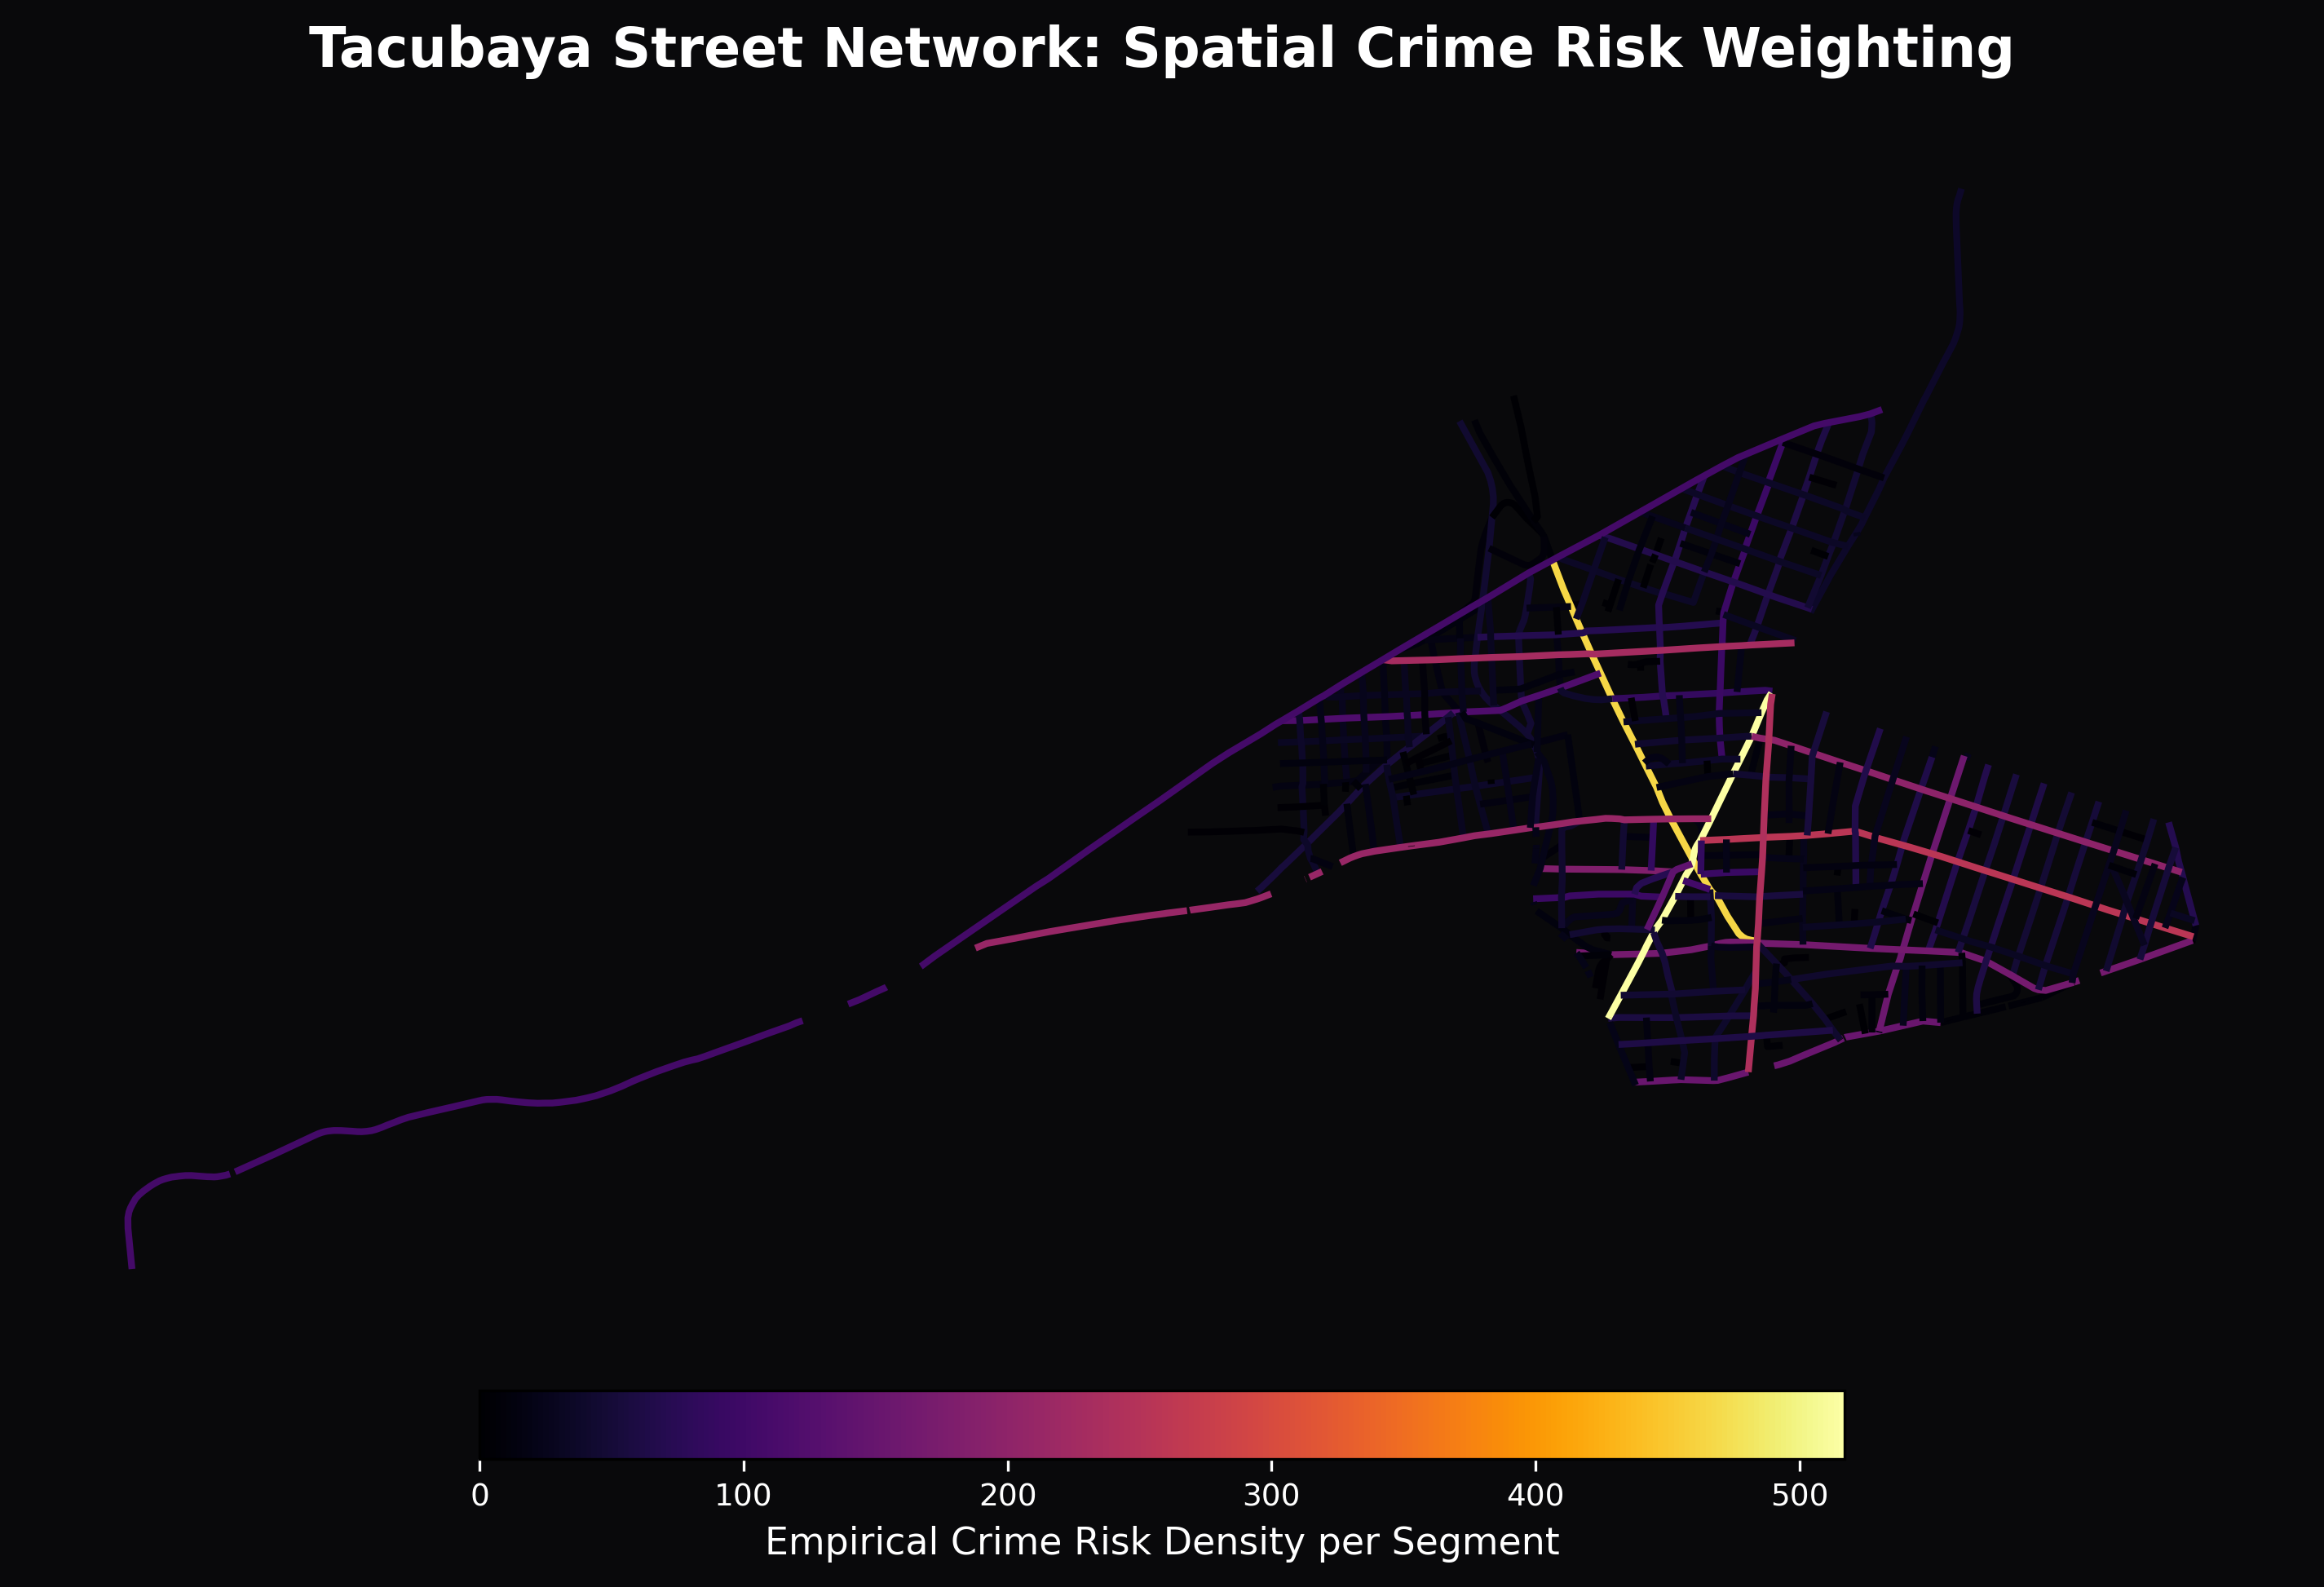

In [4]:
import glob
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import os # Import os module to check for file existence

# 1. Locate dataset paths directly from Drive/Colab environment or current content folder
# Try to find the street network file
street_matches = glob.glob("/content/**/CDXM Street Sample 1*", recursive=True)
if not street_matches:
    # Broader search if exact name not found
    street_matches = glob.glob("/content/**/*CDXM Street Sample*", recursive=True)

# Try to find the CSV file
csv_matches = glob.glob("/content/**/Crime & Safety Victimas FGJ_acumulado_2024_09.csv", recursive=True)
if not csv_matches:
    # Broader search if exact name not found
    csv_matches = glob.glob("/content/**/*FGJ_acumulado*.csv", recursive=True)

street_path = street_matches[0] if street_matches else None
csv_path = csv_matches[0] if csv_matches else None

# Path to the output weighted GeoJSON from previous steps
output_weighted_geojson = "/content/tacubaya_streets_weighted.geojson"

# 2. Load or compute spatial crime density on street segments
# Prioritize loading the pre-computed file if it exists, as it was supposed to be created
if os.path.exists(output_weighted_geojson):
    gdf_plot = gpd.read_file(output_weighted_geojson)
    print(f"Loaded pre-computed weighted GeoJSON from {output_weighted_geojson}")
elif csv_path and street_path and street_path.endswith(".gpkg"):
    print(f"Recomputing weighted GeoJSON using street data from: {street_path} and crime data from: {csv_path}")
    # Query Tacubaya crime points via DuckDB
    con = duckdb.connect()
    con.execute("INSTALL spatial; LOAD spatial;")

    query = f"""
        SELECT
            TRY_CAST(longitud AS DOUBLE) as lon,
            TRY_CAST(latitud AS DOUBLE) as lat,
            ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
        FROM read_csv_auto('{csv_path}', ignore_errors=true)
        WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
          AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
    """
    df_crime = con.execute(query).df()
    crimes = gpd.GeoDataFrame(
        df_crime,
        geometry=gpd.GeoSeries.from_wkt(df_crime["geometry_wkt"]),
        crs="EPSG:4326",
    )

    # Load streets and reproject to Mexico City Projected CRS (EPSG:6372)
    streets = gpd.read_file(street_path)
    streets_utm = streets.to_crs(epsg=6372)
    crimes_utm = crimes.to_crs(epsg=6372)

    # Clip street network to Tacubaya study area
    xmin, ymin, xmax, ymax = crimes_utm.total_bounds
    streets_clipped = streets_utm.cx[xmin:xmax, ymin:ymax].copy()

    # Buffer streets by 25m and count spatial crime intersections
    streets_buffered = streets_clipped.geometry.buffer(25)
    buffered_gdf = gpd.GeoDataFrame(
        streets_clipped.drop(columns="geometry"),
        geometry=streets_buffered,
        crs=6372,
    )

    joined = gpd.sjoin(
        crimes_utm, buffered_gdf, how="inner", predicate="within"
    )
    crime_counts = joined.index_right.value_counts()
    streets_clipped["crime_count"] = (
        streets_clipped.index.map(crime_counts).fillna(0).astype(int)
    )
    gdf_plot = streets_clipped
else:
    raise FileNotFoundError(
        f"Could not find the pre-computed weighted street network at {output_weighted_geojson}, "
        f"and also failed to locate required input files for re-computation:\n"
        f"  Street network GPKG (found: {street_path})\n"
        f"  Crime CSV (found: {csv_path})"
    )

# 3. High-Resolution Dark-Mode Rendering (300 DPI PNG + Vector SVG)
fig, ax = plt.subplots(figsize=(12, 12), facecolor="#09090b", dpi=300)
ax.set_facecolor("#09090b")

gdf_plot.plot(
    column="crime_count",
    cmap="inferno",
    linewidth=2.0,
    legend=True,
    ax=ax,
    legend_kwds={
        "label": "Empirical Crime Risk Density per Segment",
        "orientation": "horizontal",
        "shrink": 0.6,
        "pad": 0.03,
    },
)

# Format legend/colorbar labels and ticks to match dark mode (#09090b)
cbar = fig.axes[-1]
cbar.xaxis.label.set_color("white")
cbar.xaxis.label.set_fontsize(11)
cbar.tick_params(colors="white", labelsize=9)

plt.title(
    "Tacubaya Street Network: Spatial Crime Risk Weighting",
    color="white",
    fontsize=16,
    pad=20,
    fontweight="bold",
)
plt.axis("off")

# Save high-resolution raster (300 DPI) and lossless vector (SVG)
plt.savefig(
    "/content/tacubaya_street_risk_map_hd.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="#09090b",
)
plt.savefig(
    "/content/tacubaya_street_risk_map_hd.svg",
    bbox_inches="tight",
    facecolor="#09090b",
)
plt.show()

Using gdf_plot from previous cell (aQoP1cmSJ3Ho).


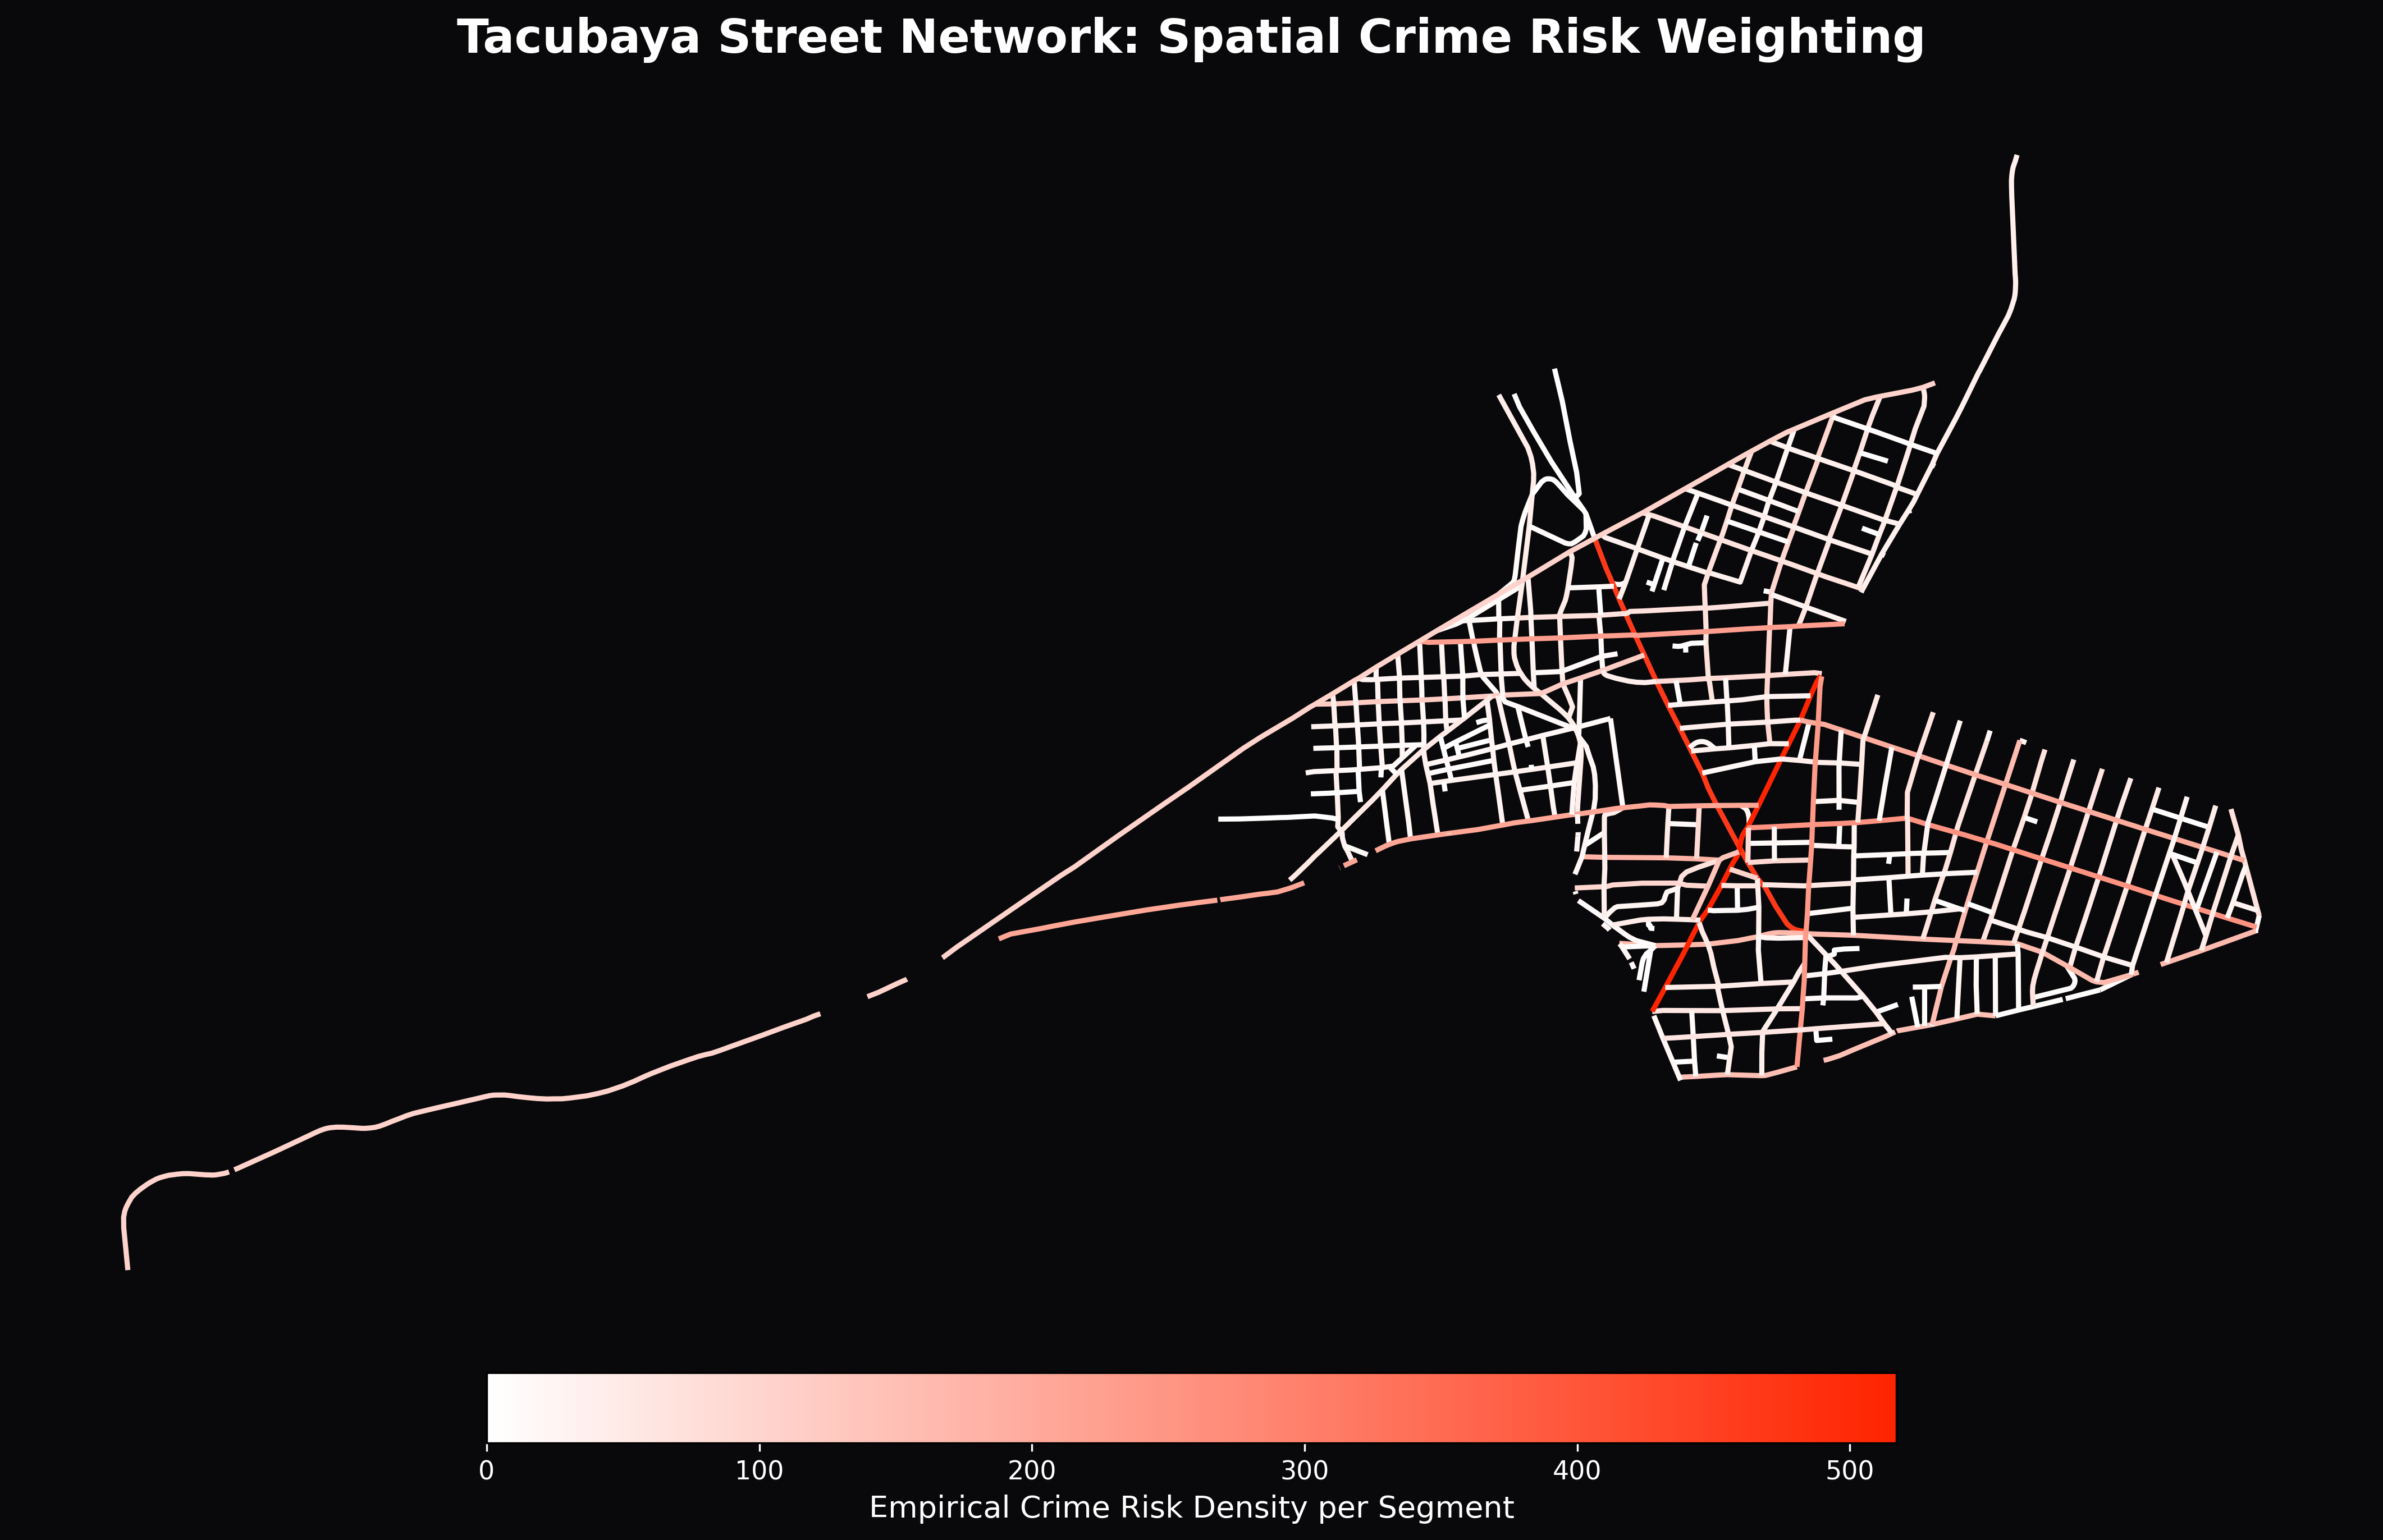

In [11]:
import glob
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import duckdb # Added for recomputation fallback

# 1. Load spatial street network dataset
# Prefer to use gdf_plot from previous cell if available, as it's already computed
if 'gdf_plot' in locals() and isinstance(gdf_plot, gpd.GeoDataFrame):
    gdf = gdf_plot
    print("Using gdf_plot from previous cell (aQoP1cmSJ3Ho).")
else:
    # If gdf_plot not available, try to load the pre-computed GeoJSON
    output_weighted_geojson = "/content/tacubaya_streets_weighted.geojson"
    if os.path.exists(output_weighted_geojson):
        gdf = gpd.read_file(output_weighted_geojson)
        print(f"Loaded weighted GeoJSON from {output_weighted_geojson}")
    else:
        # Fallback: recompute from raw files if weighted geojson is not found
        print("Weighted GeoJSON not found, attempting to recompute from raw data.")

        # Locate raw street network and crime CSV files
        street_matches = glob.glob("/content/**/CDXM Street Sample 1*", recursive=True)
        if not street_matches:
            street_matches = glob.glob("/content/**/*CDXM Street Sample*", recursive=True)

        csv_matches = glob.glob("/content/**/Crime & Safety Victimas FGJ_acumulado_2024_09.csv", recursive=True)
        if not csv_matches:
            csv_matches = glob.glob("/content/**/*FGJ_acumulado*.csv", recursive=True)

        street_path = street_matches[0] if street_matches else None
        csv_path = csv_matches[0] if csv_matches else None

        if csv_path and street_path and street_path.endswith(".gpkg"):
            print(f"Recomputing weighted GeoJSON using street data from: {street_path} and crime data from: {csv_path}")
            con = duckdb.connect()
            con.execute("INSTALL spatial; LOAD spatial;")

            query = f"""
                SELECT
                    TRY_CAST(longitud AS DOUBLE) as lon,
                    TRY_CAST(latitud AS DOUBLE) as lat,
                    ST_AsText(ST_Point(TRY_CAST(longitud AS DOUBLE), TRY_CAST(latitud AS DOUBLE))) AS geometry_wkt
                FROM read_csv_auto('{csv_path}', ignore_errors=true)
                WHERE TRY_CAST(longitud AS DOUBLE) BETWEEN -99.200 AND -99.170
                  AND TRY_CAST(latitud AS DOUBLE) BETWEEN 19.390 AND 19.415;
            """
            df_crime = con.execute(query).df()
            crimes = gpd.GeoDataFrame(
                df_crime,
                geometry=gpd.GeoSeries.from_wkt(df_crime["geometry_wkt"]),
                crs="EPSG:4326",
            )

            streets = gpd.read_file(street_path)
            streets_utm = streets.to_crs(epsg=6372)
            crimes_utm = crimes.to_crs(epsg=6372)

            xmin, ymin, xmax, ymax = crimes_utm.total_bounds
            streets_clipped = streets_utm.cx[xmin:xmax, ymin:ymax].copy()

            streets_buffered = streets_clipped.geometry.buffer(25)
            buffered_gdf = gpd.GeoDataFrame(
                streets_clipped.drop(columns="geometry"),
                geometry=streets_buffered,
                crs=6372,
            )

            joined = gpd.sjoin(
                crimes_utm, buffered_gdf, how="inner", predicate="within"
            )
            crime_counts = joined.index_right.value_counts()
            streets_clipped["crime_count"] = (
                streets_clipped.index.map(crime_counts).fillna(0).astype(int)
            )
            gdf = streets_clipped
            # Save the recomputed gdf for future use
            gdf.to_crs(epsg=4326).to_file(output_weighted_geojson, driver="GeoJSON")
            print(f"Recomputation complete. Saved to {output_weighted_geojson}")
        else:
            raise FileNotFoundError(
                f"Could not find the pre-computed weighted street network at {output_weighted_geojson}, "
                f"and also failed to locate required input files for re-computation:\n"
                f"  Street network GPKG (found: {street_path})\n"
                f"  Crime CSV (found: {csv_path})\n"
                f"Please ensure `CDXM Street Sample 1.gpkg` and `Crime & Safety Victimas FGJ_acumulado_2024_09.csv` are accessible."
            )

# Detect numerical column representing crime risk density
risk_col = 'crime_count' if 'crime_count' in gdf.columns else (
    'risk_weight' if 'risk_weight' in gdf.columns else gdf.select_dtypes(include='number').columns[0]
)

# 2. Define Custom Color Ramp: White (Least/0) -> Scarlet Red (Highest)
scarlet_red = "#FF2400"  # Hex code for Scarlet Red
cmap_custom = mcolors.LinearSegmentedColormap.from_list("white_to_scarlet", ["#FFFFFF", scarlet_red])

# 3. Setup High-Definition Canvas (300 DPI) with Dark Background
fig, ax = plt.subplots(figsize=(18, 12), facecolor='#09090b', dpi=300)
ax.set_facecolor('#09090b')

# 4. Plot Street Network using the Simplified Color Ramp
gdf.plot(
    column=risk_col,
    cmap=cmap_custom,
    linewidth=2.2,
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Empirical Crime Risk Density per Segment",
        'orientation': "horizontal",
        'shrink': 0.6,
        'pad': 0.03
    }
)

# 5. Format Title & Remove Axes
plt.title(
    "Tacubaya Street Network: Spatial Crime Risk Weighting",
    color='white',
    fontsize=20,
    pad=20,
    fontweight='bold'
)
plt.axis('off')

# 6. Format Colorbar for Dark Background
cbar = fig.axes[-1]
cbar.xaxis.label.set_color('white')
cbar.xaxis.label.set_fontsize(13)
cbar.tick_params(colors='white', labelsize=11)

# 7. Save High-Definition Outputs (PNG + Vector SVG)
plt.savefig("/content/tacubaya_street_risk_scarlet_hd.png", dpi=300, bbox_inches='tight', facecolor='#09090b')
plt.savefig("/content/tacubaya_street_risk_scarlet_hd.svg", bbox_inches='tight', facecolor='#09090b')

plt.show()

In [22]:
import os
from google.colab import userdata
import getpass

# 1. Repository Details
GITHUB_USERNAME = "georginakinuthia"
REPO_NAME = "georginakinuthia.github.io"
GITHUB_EMAIL = "your_email@example.com"  # Replace with your GitHub email
BRANCH_NAME = "main"
COMMIT_MESSAGE = "Update notebook and simulation files from Colab"

# 2. Authenticate using GitHub Personal Access Token (PAT)
# Recommended: Store your PAT in Colab Secrets (key icon on left sidebar) named 'GITHUB_TOKEN'
try:
    GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
except Exception:
    GITHUB_TOKEN = getpass.getpass("Enter your GitHub Personal Access Token (PAT): ")

# 3. Configure Git Global User Settings
!git config --global user.name "{GITHUB_USERNAME}"
!git config --global user.email "{GITHUB_EMAIL}"

# 4. Clone or Navigate to the Repository
if not os.path.exists(REPO_NAME):
    print(f"Cloning {REPO_NAME}...")
    !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
    %cd {REPO_NAME}
else:
    print(f"Navigating to {REPO_NAME}...")
    %cd {REPO_NAME}
    !git pull origin {BRANCH_NAME}

# 5. Copy new/updated files into the repository folder (if needed)
# Example: Copy updated notebook or outputs from /content into the repo working directory
!cp -r /content/*.ipynb . 2>/dev/null || true
!cp -r /content/*.geojson . 2>/dev/null || true

# 6. Stage, Commit, and Push
!git add .
!git status
!git commit -m "{COMMIT_MESSAGE}"
!git push https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git {BRANCH_NAME}

print("✅ Repository updated successfully!")

Enter your GitHub Personal Access Token (PAT): ··········
Cloning georginakinuthia.github.io...
Cloning into 'georginakinuthia.github.io'...
remote: Enumerating objects: 157, done.
remote: Total 157 (delta 0), reused 0 (delta 0), pack-reused 157 (from 1)
Receiving objects: 100% (157/157), 1.29 MiB | 4.10 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/georginakinuthia.github.io
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   tacubaya_streets_weighted.geojson

[main 8e1b2af] Update notebook and simulation files from Colab
 1 file changed, 256 insertions(+)
 create mode 100644 tacubaya_streets_weighted.geojson
Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 27.04 KiB | 4.51 MiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Res